# Error Analysis: Identify characteristics of misclassified sentences

- For the sentences that were incorrectly classified, what are the characteristics in them?
- For the ones that are classified as a prediction, do our prediction properties exist?

---

See the following

| Notebook | Experiment / Approach | Question |
|---------|----------------------|----------|
| `error_analysis-k-means.ipynb` | Visual | Can we clearly separate predictions vs. non-predictions based on embeddings alone? |
| `error_analysis-prediction_structure.ipynb` | Structural | Does future-related syntactic structure reliably indicate a prediction? |
| `error_analysis-agreement.ipynb` | Agreement | How much does high model agreement and incorrect majority vote exist within each class (tp, fn, tn, fp)? |
| `error_analysis-prediction_words.ipynb` | Lexical | What percentage of predictive words are in each class (tp, fn, tn, fp)? |

In [ ]:
import os
import sys

import pandas as pd

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../'))

from data_processing import DataProcessing
from feature_extraction import SpacyFeatureExtraction

In [2]:
pd.set_option('max_colwidth', 800)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_columns', 40)
# pd.set_option('display.max_rows', None)

## Load Data

In [3]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
# combine_data_path = os.path.join(base_data_path, 'financial_phrase_bank/combined_generated_fin_phrase_bank')
train_data = os.path.join(base_data_path, 'classification_results/train_synthetic-v1_2026-03-23/seed3')

In [4]:
# model_results_path = os.path.join(combine_data_path, 'inference_chronicle2050_2026-03-07_21-51-47.csv')
test_data = os.path.join(train_data, 'external_fpb-maya-binary-imbalanced-96d-v1/', 'ml_classifiers_fpb-maya-binary-imbalanced-96d-v1.csv')

model_results_df = DataProcessing.load_from_file(test_data, 'csv', sep=',')
cols_to_drop = ["Dataset Name", "Author Type", "maya_label"]
compare_y_vs_yhats_df = DataProcessing.drop_df_columns(model_results_df, cols_to_drop)
compare_y_vs_yhats_df

,Base Sentence,Sentence Label,Base Sentence Embedding,perceptron,sgd_classifier,logistic_regression,ridge_classifier,decision_tree_classifier,random_forest_classifier,gradient_boosting_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier
0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....,1,1,1,1,0,1,1,1,1
1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....,1,1,0,0,1,1,1,0,1
2,TeliaSonera TLSN said the offer is in line with its strategy to increase its ownership in core business holdings and would strengthen Eesti Telekom 's offering to its customers .,1,[ 1.15080299e-02 1.98225155e-01 1.95062440e-02 -5.97744621e-02\n 1.75585955e-01 -1.25474662e-01 -3.72287892e-02 -2.83286646e-02\n -3.56662273e-02 1.96045303e+00 -2.79843062e-01 -1.04898110e-01\n 4.49508205e-02 1.31481076e-02 6.55795187e-02 -4.11130209e-03\n -5.56710083e-03 1.11790729e+00 -1.21459611e-01 -9.75316912e-02\n 2.18506586e-02 1.38311490e-01 9.17155594e-02 -5.85136563e-02\n 1.03342809e-01 7.32071251e-02 -3.92427929e-02 1.13294438e-01\n -1.07247204e-01 5.58346435e-02 -9.28281173e-02 5.48683619e-03\n -1.84886660e-02 5.24056628e-02 4.05881368e-02 -8.35432187e-02\n 1.13391867e-02 2.78038122e-02 -5.44880610e-03 -1.02035753e-01\n -6.69988245e-02 7.79658780e-02 5.37769347e-02 -1.39616817e-01\n 2.96867881e-02 1.13102477e-02 -3.53476144e-02 -1.88835058e-02\n -4....,1,1,1,1,1,1,1,1,1
3,"STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMENE Credit Suisse First Boston ( CFSB ) raised the fair value for shares in four of the largest Nordic forestry groups .",1,[-5.94305294e-03 1.57299116e-01 -1.01663664e-01 -4.74716797e-02\n 1.79840446e-01 2.63532978e-02 4.07044962e-02 -3.17418873e-02\n -1.32127828e-03 1.28309309e+00 -3.01563025e-01 4.19499092e-02\n 4.76229452e-02 -1.16947450e-01 -1.42535036e-02 2.37643998e-02\n -3.57760116e-02 8.38545859e-01 -5.43218441e-02 2.42432952e-03\n 7.67285563e-03 4.88467440e-02 4.74129207e-02 -2.67546187e-04\n 6.47759363e-02 7.66171236e-03 -7.71588413e-03 6.14660196e-02\n 9.25298501e-03 1.29891783e-01 6.76145032e-02 -7.35822739e-03\n 3.22291143e-02 1.50113806e-01 1.32441163e-01 -9.81159508e-03\n -1.3941115

In [5]:
model_col_names = compare_y_vs_yhats_df.columns.to_list()[3:]
model_col_names, len(model_col_names)

(['perceptron',
  'sgd_classifier',
  'logistic_regression',
  'ridge_classifier',
  'decision_tree_classifier',
  'random_forest_classifier',
  'gradient_boosting_classifier',
  'support_vector_machine_classifier',
  'x_gradient_boosting_classifier'],
 9)

In [6]:
compare_y_vs_mv_df = compare_y_vs_yhats_df[model_col_names].mode(axis=1)
compare_y_vs_yhats_df['Majority Vote'] = compare_y_vs_mv_df
compare_y_vs_yhats_df

,Base Sentence,Sentence Label,Base Sentence Embedding,perceptron,sgd_classifier,logistic_regression,ridge_classifier,decision_tree_classifier,random_forest_classifier,gradient_boosting_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier,Majority Vote
0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....,1,1,1,1,0,1,1,1,1,1
1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....,1,1,0,0,1,1,1,0,1,1
2,TeliaSonera TLSN said the offer is in line with its strategy to increase its ownership in core business holdings and would strengthen Eesti Telekom 's offering to its customers .,1,[ 1.15080299e-02 1.98225155e-01 1.95062440e-02 -5.97744621e-02\n 1.75585955e-01 -1.25474662e-01 -3.72287892e-02 -2.83286646e-02\n -3.56662273e-02 1.96045303e+00 -2.79843062e-01 -1.04898110e-01\n 4.49508205e-02 1.31481076e-02 6.55795187e-02 -4.11130209e-03\n -5.56710083e-03 1.11790729e+00 -1.21459611e-01 -9.75316912e-02\n 2.18506586e-02 1.38311490e-01 9.17155594e-02 -5.85136563e-02\n 1.03342809e-01 7.32071251e-02 -3.92427929e-02 1.13294438e-01\n -1.07247204e-01 5.58346435e-02 -9.28281173e-02 5.48683619e-03\n -1.84886660e-02 5.24056628e-02 4.05881368e-02 -8.35432187e-02\n 1.13391867e-02 2.78038122e-02 -5.44880610e-03 -1.02035753e-01\n -6.69988245e-02 7.79658780e-02 5.37769347e-02 -1.39616817e-01\n 2.96867881e-02 1.13102477e-02 -3.53476144e-02 -1.88835058e-02\n -4....,1,1,1,1,1,1,1,1,1,1
3,"STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMENE Credit Suisse First Boston ( CFSB ) raised the fair value for shares in four of the largest Nordic forestry groups .",1,[-5.94305294e-03 1.57299116e-01 -1.01663664e-01 -4.74716797e-02\n 1.79840446e-01 2.63532978e-02 4.07044962e-02 -3.17418873e-02\n -1.32127828e-03 1.28309309e+00 -3.01563025e-01 4.19499092e-02\n 4.76229452e-02 -1.16947450e-01 -1.42535036e-02 2.37643998e-02\n -3.57760116e-02 8.38545859e-01 -5.43218441e-02 2.42432952e-03\n 7.67285563e-03 4.88467440e-02 4.74129207e-02 -2.67546187e-04\n 6.47759363e-02 7.66171236e-03 -7.71588413e-03 6.14660196e-02\n 9.25298501e-03 1.29891783e-01 6.76145032e-02 -7.35822739e-03\n 3.22291143e-02 1.50113806e-01 1.32441163e-01 -9.81159

In [7]:
model_col_names

['perceptron',
 'sgd_classifier',
 'logistic_regression',
 'ridge_classifier',
 'decision_tree_classifier',
 'random_forest_classifier',
 'gradient_boosting_classifier',
 'support_vector_machine_classifier',
 'x_gradient_boosting_classifier']

In [8]:
meta_data = compare_y_vs_yhats_df.iloc[:, 2:-1]
meta_data

,Base Sentence Embedding,perceptron,sgd_classifier,logistic_regression,ridge_classifier,decision_tree_classifier,random_forest_classifier,gradient_boosting_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier
0,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....,1,1,1,1,0,1,1,1,1
1,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....,1,1,0,0,1,1,1,0,1
2,[ 1.15080299e-02 1.98225155e-01 1.95062440e-02 -5.97744621e-02\n 1.75585955e-01 -1.25474662e-01 -3.72287892e-02 -2.83286646e-02\n -3.56662273e-02 1.96045303e+00 -2.79843062e-01 -1.04898110e-01\n 4.49508205e-02 1.31481076e-02 6.55795187e-02 -4.11130209e-03\n -5.56710083e-03 1.11790729e+00 -1.21459611e-01 -9.75316912e-02\n 2.18506586e-02 1.38311490e-01 9.17155594e-02 -5.85136563e-02\n 1.03342809e-01 7.32071251e-02 -3.92427929e-02 1.13294438e-01\n -1.07247204e-01 5.58346435e-02 -9.28281173e-02 5.48683619e-03\n -1.84886660e-02 5.24056628e-02 4.05881368e-02 -8.35432187e-02\n 1.13391867e-02 2.78038122e-02 -5.44880610e-03 -1.02035753e-01\n -6.69988245e-02 7.79658780e-02 5.37769347e-02 -1.39616817e-01\n 2.96867881e-02 1.13102477e-02 -3.53476144e-02 -1.88835058e-02\n -4....,1,1,1,1,1,1,1,1,1
3,[-5.94305294e-03 1.57299116e-01 -1.01663664e-01 -4.74716797e-02\n 1.79840446e-01 2.63532978e-02 4.07044962e-02 -3.17418873e-02\n -1.32127828e-03 1.28309309e+00 -3.01563025e-01 4.19499092e-02\n 4.76229452e-02 -1.16947450e-01 -1.42535036e-02 2.37643998e-02\n -3.57760116e-02 8.38545859e-01 -5.43218441e-02 2.42432952e-03\n 7.67285563e-03 4.88467440e-02 4.74129207e-02 -2.67546187e-04\n 6.47759363e-02 7.66171236e-03 -7.71588413e-03 6.14660196e-02\n 9.25298501e-03 1.29891783e-01 6.76145032e-02 -7.35822739e-03\n 3.22291143e-02 1.50113806e-01 1.32441163e-01 -9.81159508e-03\n -1.39411157e-02 1.04931206e-03 -1.90248825e-02 -9.27351974e-03\n -2.62032263e-02 7.86117762e-02 8.33134279e-02 2.64521260e-02\n -1.58701912e-02 9.79095325e-03 3.53994928e-02 -1.72072705e-02\n 7....,0,0,0,0,1,0,0,0,0
4,[-9.75671411e-02 2.17742935e-01 -5.24893478e-02 2.29859371e-02\n 1.95262451e-02 -3.96593288e-02 -2.93270722e-02 1.45730842e-02\n 8.01267326e-02 2.14558053e+00 -3.02207738e-01 7.73812085e-02\n 9.75400433e-02 -5.86019419e-02 2.85570417e-02 -6.01695329e-02\n -6.48141513e-03 1.10976875e+00 -1.62209153e-01 -2.63800696e-02\n 6.90186918e-02 5.40496930e-02 -4.89046909e-02 -1.06065851e-02\n 3.81638743e-02 8.63624960e-02 -1.46540195e-01 -7.51399994e-02\n -5.42312972e-02 -2.43689902e-02 3.15490589e-02 -7.77387097e-02\n -1.04405805e-01 1.55526847e-01 2.55947262e-02 -2.01004483e-02\n -4.3354682

In [9]:
meta_data = compare_y_vs_yhats_df.iloc[:, 3:-1]
compare_y_vs_yhats_df['Meta Data'] = meta_data.to_dict(orient='records')
compare_y_vs_yhats_df
y_vs_yhats_df = DataProcessing.drop_df_columns(compare_y_vs_yhats_df, meta_data.columns.to_list())
y_vs_yhats_df


,Base Sentence,Sentence Label,Base Sentence Embedding,Majority Vote,Meta Data
0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....,1,"{'perceptron': 1, 'sgd_classifier': 1, 'logistic_regression': 1, 'ridge_classifier': 1, 'decision_tree_classifier': 0, 'random_forest_classifier': 1, 'gradient_boosting_classifier': 1, 'support_vector_machine_classifier': 1, 'x_gradient_boosting_classifier': 1}"
1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....,1,"{'perceptron': 1, 'sgd_classifier': 1, 'logistic_regression': 0, 'ridge_classifier': 0, 'decision_tree_classifier': 1, 'random_forest_classifier': 1, 'gradient_boosting_classifier': 1, 'support_vector_machine_classifier': 0, 'x_gradient_boosting_classifier': 1}"
2,TeliaSonera TLSN said the offer is in line with its strategy to increase its ownership in core business holdings and would strengthen Eesti Telekom 's offering to its customers .,1,[ 1.15080299e-02 1.98225155e-01 1.95062440e-02 -5.97744621e-02\n 1.75585955e-01 -1.25474662e-01 -3.72287892e-02 -2.83286646e-02\n -3.56662273e-02 1.96045303e+00 -2.79843062e-01 -1.04898110e-01\n 4.49508205e-02 1.31481076e-02 6.55795187e-02 -4.11130209e-03\n -5.56710083e-03 1.11790729e+00 -1.21459611e-01 -9.75316912e-02\n 2.18506586e-02 1.38311490e-01 9.17155594e-02 -5.85136563e-02\n 1.03342809e-01 7.32071251e-02 -3.92427929e-02 1.13294438e-01\n -1.07247204e-01 5.58346435e-02 -9.28281173e-02 5.48683619e-03\n -1.84886660e-02 5.24056628e-02 4.05881368e-02 -8.35432187e-02\n 1.13391867e-02 2.78038122e-02 -5.44880610e-03 -1.02035753e-01\n -6.69988245e-02 7.79658780e-02 5.37769347e-02 -1.39616817e-01\n 2.96867881e-02 1.13102477e-02 -3.53476144e-02 -1.88835058e-02\n -4....,1,"{'perceptron': 1, 'sgd_classifier': 1, 'logistic_regression': 1, 'ridge_classifier': 1, 'decision_tree_classifier': 1, 'random_forest_classifier': 1, 'gradient_boosting_classifier': 1, 'support_vector_machine_classifier': 1, 'x_gradient_boosting_classifier': 1}"
3,"STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMENE Credit Suisse First Boston ( CFSB ) raised the fair value for shares in four of the largest Nordic forestry groups .",1,[-5.94305294e-03 1.572

## Get class of each sentence

- [ ] True Label vs Majority Vote
- [ ] True Label vs Each Model

## True Label vs Majority Vote

In [10]:
def classification_of_mv_sentence(df):
    copy_df = df.copy()
    copy_df['Class'] = None

    for idx, row in copy_df.iterrows():
        y = row['Sentence Label']
        y_hat = row['Majority Vote']

        # y = 1 (positive class)
        if y == 1:
            if y_hat == 1:  # TP
                copy_df.loc[idx, 'Class'] = "TP"
            else:  # FN
                copy_df.loc[idx, 'Class'] = "FN"

        # y = 0 (negative class)
        elif y == 0:
            if y_hat == 0:  # TN
                copy_df.loc[idx, 'Class'] = "TN"
            else:  # FP
                copy_df.loc[idx, 'Class'] = "FP"

    return copy_df

In [11]:
mv_with_class_df = classification_of_mv_sentence(y_vs_yhats_df)
mv_with_class_df

,Base Sentence,Sentence Label,Base Sentence Embedding,Majority Vote,Meta Data,Class
0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....,1,"{'perceptron': 1, 'sgd_classifier': 1, 'logistic_regression': 1, 'ridge_classifier': 1, 'decision_tree_classifier': 0, 'random_forest_classifier': 1, 'gradient_boosting_classifier': 1, 'support_vector_machine_classifier': 1, 'x_gradient_boosting_classifier': 1}",TP
1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....,1,"{'perceptron': 1, 'sgd_classifier': 1, 'logistic_regression': 0, 'ridge_classifier': 0, 'decision_tree_classifier': 1, 'random_forest_classifier': 1, 'gradient_boosting_classifier': 1, 'support_vector_machine_classifier': 0, 'x_gradient_boosting_classifier': 1}",TP
2,TeliaSonera TLSN said the offer is in line with its strategy to increase its ownership in core business holdings and would strengthen Eesti Telekom 's offering to its customers .,1,[ 1.15080299e-02 1.98225155e-01 1.95062440e-02 -5.97744621e-02\n 1.75585955e-01 -1.25474662e-01 -3.72287892e-02 -2.83286646e-02\n -3.56662273e-02 1.96045303e+00 -2.79843062e-01 -1.04898110e-01\n 4.49508205e-02 1.31481076e-02 6.55795187e-02 -4.11130209e-03\n -5.56710083e-03 1.11790729e+00 -1.21459611e-01 -9.75316912e-02\n 2.18506586e-02 1.38311490e-01 9.17155594e-02 -5.85136563e-02\n 1.03342809e-01 7.32071251e-02 -3.92427929e-02 1.13294438e-01\n -1.07247204e-01 5.58346435e-02 -9.28281173e-02 5.48683619e-03\n -1.84886660e-02 5.24056628e-02 4.05881368e-02 -8.35432187e-02\n 1.13391867e-02 2.78038122e-02 -5.44880610e-03 -1.02035753e-01\n -6.69988245e-02 7.79658780e-02 5.37769347e-02 -1.39616817e-01\n 2.96867881e-02 1.13102477e-02 -3.53476144e-02 -1.88835058e-02\n -4....,1,"{'perceptron': 1, 'sgd_classifier': 1, 'logistic_regression': 1, 'ridge_classifier': 1, 'decision_tree_classifier': 1, 'random_forest_classifier': 1, 'gradient_boosting_classifier': 1, 'support_vector_machine_classifier': 1, 'x_gradient_boosting_classifier': 1}",TP
3,"STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMENE Credit Suisse First Boston ( CFSB ) raised the fair value for shares in four of the largest Nordic forestry groups .",1,[-5.943

In [12]:
filt_fp = (mv_with_class_df['Class'] == 'FP')
mv_with_class_df[filt_fp]

,Base Sentence,Sentence Label,Base Sentence Embedding,Majority Vote,Meta Data,Class
458,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",0,[ 2.75615864e-02 1.79783881e-01 -1.21603109e-01 -1.75067633e-01\n 9.83876437e-02 -2.84420680e-02 7.04421336e-03 -1.00048631e-01\n -7.77818933e-02 2.37184715e+00 -2.96325952e-01 4.51707616e-02\n 7.32708871e-02 3.28064598e-02 -9.75645557e-02 -1.34704620e-01\n -1.46236047e-02 1.19266689e+00 -1.20833769e-01 -2.11537201e-02\n 4.45679054e-02 2.58689113e-02 -2.11139992e-02 -4.58938554e-02\n -1.82265490e-02 6.69947565e-02 -9.96832177e-02 1.51548507e-02\n 1.27175581e-02 -8.47315788e-02 -2.66740546e-02 2.18095612e-02\n 6.70658797e-02 1.45969734e-01 1.41264692e-01 6.51224284e-04\n 4.73446399e-02 -1.93405268e-03 3.11274361e-02 -1.58938453e-01\n 2.45406702e-02 6.88584819e-02 1.01522245e-01 -1.50205001e-01\n -1.53623046e-02 4.58216853e-03 -6.17812127e-02 -9.76008475e-02\n 3....,1,"{'perceptron': 1, 'sgd_classifier': 1, 'logistic_regression': 1, 'ridge_classifier': 1, 'decision_tree_classifier': 1, 'random_forest_classifier': 1, 'gradient_boosting_classifier': 1, 'support_vector_machine_classifier': 1, 'x_gradient_boosting_classifier': 1}",FP
459,"Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .",0,[ 2.36152317e-02 1.75637215e-01 -4.75921258e-02 -1.00200571e-01\n 8.89781415e-02 -6.43718988e-02 -2.69504562e-02 -4.83372882e-02\n 8.36279336e-03 2.23455858e+00 -2.08360046e-01 -7.23112794e-03\n 8.49666148e-02 1.64331440e-02 -6.58765361e-02 -4.59754653e-03\n 4.57342863e-02 1.37366998e+00 -2.09634945e-01 -1.05597727e-01\n 5.03051467e-03 6.17915466e-02 -7.04549477e-02 -7.91235566e-02\n 3.26408111e-02 -1.15197964e-01 -5.03080897e-02 5.12997098e-02\n 2.39542034e-02 -1.31541165e-02 5.15889144e-03 -1.93684064e-02\n 2.15651724e-03 3.74105498e-02 1.53509766e-01 -1.50099948e-01\n -2.85472199e-02 7.28019401e-02 1.21796988e-02 -5.34533598e-02\n 3.01733967e-02 1.60360977e-01 9.51667279e-02 -1.36446133e-01\n -4.18400392e-02 -9.26042721e-03 -9.38620940e-02 -4.67620976e-02\n 6....,1,"{'perceptron': 1, 'sgd_classifier': 1, 'logistic_regression': 1, 'ridge_classifier': 1, 'decision_tree_classifier': 1, 'random_forest_classifier': 0, 'gradient_boosting_classifier': 1, 'support_vector_machine_classifier': 1, 'x_gradient_boosting_classifier': 1}",FP
473,"Its board of directors will propose a dividend of EUR0 .12 per share for 2010 , up from the EUR0 .08 per share paid in 2009 .",0,[-1.31687850e-01 1.12504549e-01 1.16494456e-02 -2.67163999e-02\n -3.56583372e-02 -6.02459237e-02 8.92892852e-02 -1.13993369e-01\n 1.42705552e-02 1.82348073e+00 -3.89135599e-01 1.58573151e-01\n 3.60858962e-02 -9.51433368e-03 -3.51401721e-03 -1.04351744e-01\n -4.07603793e-02 1.12848067e+00 -1.53742373e-01 -3.50933545e-03\n 3.96641493e-02 6.87583676e-03 -4.38601300e-02 -1.21602066e-01\n 1.31883547e-01 1.33860916e-01 -1.14144176e-01 -3.39329406e-03\n 1.02582075e-01 1.38460755e-01 1.67863071e-02 -8.58858973e-02\n -9.02971849e-02 1.32979512e-01 -1.20643713e-02 -3.31787951e-02\n -1.21340953e-01 -6.01888038e-02 -3.43275853e-02 -3.34232636e-02\n 1.52784446e-02 1.39206484e-01 1.49177745e-01 4.48596776e-02\n 7.95120075e-02 7.31440866e-03 2.32526101e-03 1.31328702e-02\n -7....,1,"{'perceptron': 1, 'sgd_classifier': 1, 'logistic_regression': 1, 'ridge_classifier': 1, 'decision_tree_classifier': 1, 'random_forest_classifier': 1, 'gradient_boosting_classifier': 1, 'support_vector_machine_classifier': 1, 'x_gradient_boosting_classifier': 1}",FP
496,"Nyrstar has also agreed to supply to Talvivaara up to 150,000 tonnes of sulphuric acid per annum for use in Talvivaara 's leaching process during the period of supply of the zinc in concentrate .",0,[-4.98915724e-02 2.06232026e-01 -1.91987175e-02 1.96848959e-02\n -7.42411390e-02 -5.51822770e-04 -8.50609317

### True Label vs Each Model

- Per y and $y_{hat}$
- Per model
- Possibly realign where all models disagree on misalignment. Or, maybe not as worse case could be they misalign?

In [13]:
def classification_of_sentence(df, model_col_names):
    classification_dfs = []
    tps, fns, tns, fps = [], [], [], []

    for idx, row in df.iterrows():
        sentence = row['Base Sentence']
        y = row['Sentence Label']
        embedding = row["Base Sentence Embedding"]

        for model_col_name in model_col_names:
            y_hat = row[model_col_name]

            # y = 1 (positive class)
            if y == 1:
                if y_hat == 1:  # TP
                    tps.append((idx, sentence, y, y_hat, model_col_name, embedding))
                else:  # FN
                    fn = (idx, sentence, y, y_hat, model_col_name, embedding)
                    fns.append(fn)
                    if idx < 3:
                        print(f"{idx}-{sentence}")
                        print(f"\tMismatch: {fn}")

            # y = 0 (negative class)
            elif y == 0:
                if y_hat == 0:  # TN
                    tns.append((idx, sentence, y, y_hat, model_col_name, embedding))
                else:  # FP
                    fp = (idx, sentence, y, y_hat, model_col_name, embedding)
                    fps.append(fp)
                    if idx < 3:
                        print(f"{idx}-{sentence}")
                        print(f"\tMismatch: {fp}")

    # Build outputs
    col_names = ["Row", "Sentence", "True Label", "Model Label", "Model Name", "Embedding"]
    tps_df = pd.DataFrame(tps, columns=col_names)
    classification_dfs.append(tps_df)

    tns_df = pd.DataFrame(tns, columns=col_names)
    classification_dfs.append(tns_df)

    fns_df = pd.DataFrame(fns, columns=col_names)
    classification_dfs.append(fns_df)

    fps_df = pd.DataFrame(fps, columns=col_names)
    classification_dfs.append(fps_df)


    return classification_dfs

In [14]:
# meta_data_df = pd.DataFrame(y_vs_yhats_df['Meta Data'].tolist())
# meta_data_df

In [15]:
classification_dfs = classification_of_sentence(compare_y_vs_yhats_df, model_col_names)

0-With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .
	Mismatch: (0, 'With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .', 1, 0, 'decision_tree_classifier', '[-1.22568220e-01  2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02  3.63291465e-02 -1.27964811e-02  7.17335939e-02\n -1.18364163e-01  2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n  1.25499114e-01  7.25146085e-02  6.57393187e-02 -5.76901138e-02\n -2.05907249e-03  1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n  2.22120117e-02  1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03  6.18153140e-02 -5.48806489e-02  2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02  3.87728140e-02\n -5

| $ y $ | $ y_{hat} $ | Outcome |
|----------------|----------------|----------|
| 1              | 1              | **TP**   |
| 1              | 0              | **FN**  (miss out) |
| 0              | 0              | **TN**   |
| 0              | 1              | **FP**  (inflate) |

**Confusion Matrix (sklearn-style layout)**

| y \ y_hat |   0   |   1   |
|-----------|-------|-------|
| **0**     |  TN   |  FP  (inflate) |
| **1**     |  FN  (miss out) |  TP   |

In [16]:
classification_dfs = classification_of_sentence(y_vs_yhats_df, model_col_names)

KeyError: 'perceptron'

In [18]:
tps_df, tns_df, fns_df, fps_df = classification_dfs[0], classification_dfs[1], classification_dfs[2], classification_dfs[3]
len(tps_df), len(tns_df), len(fns_df), len(fps_df)

(3279, 22712, 843, 16780)

In [19]:
tps_df

,Row,Sentence,True Label,Model Label,Model Name,Embedding
0,0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,1,perceptron,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....
1,0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,1,sgd_classifier,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....
2,0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,1,logistic_regression,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....
3,0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,1,ridge_classifier,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-

In [20]:
tns_df

,Row,Sentence,True Label,Model Label,Model Name,Embedding
0,459,"Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .",0,0,random_forest_classifier,[ 2.36152317e-02 1.75637215e-01 -4.75921258e-02 -1.00200571e-01\n 8.89781415e-02 -6.43718988e-02 -2.69504562e-02 -4.83372882e-02\n 8.36279336e-03 2.23455858e+00 -2.08360046e-01 -7.23112794e-03\n 8.49666148e-02 1.64331440e-02 -6.58765361e-02 -4.59754653e-03\n 4.57342863e-02 1.37366998e+00 -2.09634945e-01 -1.05597727e-01\n 5.03051467e-03 6.17915466e-02 -7.04549477e-02 -7.91235566e-02\n 3.26408111e-02 -1.15197964e-01 -5.03080897e-02 5.12997098e-02\n 2.39542034e-02 -1.31541165e-02 5.15889144e-03 -1.93684064e-02\n 2.15651724e-03 3.74105498e-02 1.53509766e-01 -1.50099948e-01\n -2.85472199e-02 7.28019401e-02 1.21796988e-02 -5.34533598e-02\n 3.01733967e-02 1.60360977e-01 9.51667279e-02 -1.36446133e-01\n -4.18400392e-02 -9.26042721e-03 -9.38620940e-02 -4.67620976e-02\n 6....
1,460,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",0,0,perceptron,[ 6.38937727e-02 1.07207559e-01 1.42669762e-02 -1.10255882e-01\n 5.71931861e-02 -7.44904727e-02 -6.87297285e-02 -5.15912734e-02\n -4.91348691e-02 2.26488733e+00 -2.35645220e-01 -5.17288633e-02\n 6.40103146e-02 -1.21718697e-01 -7.06169829e-02 -7.73756132e-02\n -1.94147006e-02 1.01162577e+00 -9.57364291e-02 -3.53218615e-02\n 6.49149194e-02 1.41497374e-01 -5.62819093e-02 -8.65271967e-03\n 9.18274000e-02 -9.56298783e-03 -1.77566573e-01 9.82310716e-03\n -1.13442028e-02 -1.02812070e-02 3.01628970e-02 -8.26661102e-03\n -1.47392139e-01 8.76323879e-02 4.37267423e-02 5.02964184e-02\n -1.36362284e-01 6.21672459e-02 2.39139330e-02 9.83950123e-03\n 2.01519504e-02 6.74011931e-02 8.08727369e-02 -7.34586567e-02\n 2.04947442e-02 -5.54246791e-02 -7.21987188e-02 -1.01516275e-02\n 1....
2,460,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",0,0,sgd_classifier,[ 6.38937727e-02 1.07207559e-01 1.42669762e-02 -1.10255882e-01\n 5.71931861e-02 -7.44904727e-02 -6.87297285e-02 -5.15912734e-02\n -4.91348691e-02 2.26488733e+00 -2.35645220e-01 -5.17288633e-02\n 6.40103146e-02 -1.21718697e-01 -7.06169829e-02 -7.73756132e-02\n -1.94147006e-02 1.01162577e+00 -9.57364291e-02 -3.53218615e-02\n 6.49149194e-02 1.41497374e-01 -5.62819093e-02 -8.65271967e-03\n 9.18274000e-02 -9.56298783e-03 -1.77566573e-01 9.82310716e-03\n -1.13442028e-02 -1.02812070e-02 3.01628970e-02 -8.26661102e-03\n -1.47392139e-01 8.76323879e-02 4.37267423e-02 5.02964184e-02\n -1.36362284e-01 6.21672459e-02 2.39139330e-02 9.83950123e-03\n 2.01519504e-02 6.74011931e-02 8.08727369e-02 -7.34586567e-02\n 2.04947442e-02 -5.54246791e-02 -7.21987188e-02 -1.01516275e-02\n 1....
3,460,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",0,0,logistic_regression,[ 6.38937727e-02 1.07207559e-01 1.42669762e-02 -1.10255882e-01\n 5.71931861e-02 -7.44904727e-02 -6.87297285e-02 -5.15912734e-02\n -4.91348691e-02 2.26488733e+00 -2.35645220e-01 -5.17288633e-02\n 6.40103146e-02 -1.21718697e-01 -7.06169829e-02 -7.73756132e-02\n -1.94147006e-02 1.01162577e+00 -9.57364291e-02 -3.53218615e-02\n 6.49149194e-02 1.41497374e-01 -5.62819093e-02 -8.65271967e-03\n 9.18274000e-02 -9.56298783e-03 -1.77566573e-01 9.82310716e-03\n -1.13442028e-02 -1.02812070e-02 3.01628970e-02 -8.26661102e-03\n -1.47392139e-01 8.76323879e-02 4.37267423e-02 5.02964184e-02\n -1.36362284e-01 6.21672459e-02 

In [21]:
fns_df

,Row,Sentence,True Label,Model Label,Model Name,Embedding
0,0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,0,decision_tree_classifier,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....
1,1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,0,logistic_regression,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....
2,1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,0,ridge_classifier,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....
3,1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,0,support_vector_machine_classifier,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644

In [22]:
fps_df.head(10)

,Row,Sentence,True Label,Model Label,Model Name,Embedding
0,458,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",0,1,perceptron,[ 2.75615864e-02 1.79783881e-01 -1.21603109e-01 -1.75067633e-01\n 9.83876437e-02 -2.84420680e-02 7.04421336e-03 -1.00048631e-01\n -7.77818933e-02 2.37184715e+00 -2.96325952e-01 4.51707616e-02\n 7.32708871e-02 3.28064598e-02 -9.75645557e-02 -1.34704620e-01\n -1.46236047e-02 1.19266689e+00 -1.20833769e-01 -2.11537201e-02\n 4.45679054e-02 2.58689113e-02 -2.11139992e-02 -4.58938554e-02\n -1.82265490e-02 6.69947565e-02 -9.96832177e-02 1.51548507e-02\n 1.27175581e-02 -8.47315788e-02 -2.66740546e-02 2.18095612e-02\n 6.70658797e-02 1.45969734e-01 1.41264692e-01 6.51224284e-04\n 4.73446399e-02 -1.93405268e-03 3.11274361e-02 -1.58938453e-01\n 2.45406702e-02 6.88584819e-02 1.01522245e-01 -1.50205001e-01\n -1.53623046e-02 4.58216853e-03 -6.17812127e-02 -9.76008475e-02\n 3....
1,458,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",0,1,sgd_classifier,[ 2.75615864e-02 1.79783881e-01 -1.21603109e-01 -1.75067633e-01\n 9.83876437e-02 -2.84420680e-02 7.04421336e-03 -1.00048631e-01\n -7.77818933e-02 2.37184715e+00 -2.96325952e-01 4.51707616e-02\n 7.32708871e-02 3.28064598e-02 -9.75645557e-02 -1.34704620e-01\n -1.46236047e-02 1.19266689e+00 -1.20833769e-01 -2.11537201e-02\n 4.45679054e-02 2.58689113e-02 -2.11139992e-02 -4.58938554e-02\n -1.82265490e-02 6.69947565e-02 -9.96832177e-02 1.51548507e-02\n 1.27175581e-02 -8.47315788e-02 -2.66740546e-02 2.18095612e-02\n 6.70658797e-02 1.45969734e-01 1.41264692e-01 6.51224284e-04\n 4.73446399e-02 -1.93405268e-03 3.11274361e-02 -1.58938453e-01\n 2.45406702e-02 6.88584819e-02 1.01522245e-01 -1.50205001e-01\n -1.53623046e-02 4.58216853e-03 -6.17812127e-02 -9.76008475e-02\n 3....
2,458,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",0,1,logistic_regression,[ 2.75615864e-02 1.79783881e-01 -1.21603109e-01 -1.75067633e-01\n 9.83876437e-02 -2.84420680e-02 7.04421336e-03 -1.00048631e-01\n -7.77818933e-02 2.37184715e+00 -2.96325952e-01 4.51707616e-02\n 7.32708871e-02 3.28064598e-02 -9.75645557e-02 -1.34704620e-01\n -1.46236047e-02 1.19266689e+00 -1.20833769e-01 -2.11537201e-02\n 4.45679054e-02 2.58689113e-02 -2.11139992e-02 -4.58938554e-02\n -1.82265490e-02 6.69947565e-02 -9.96832177e-02 1.51548507e-02\n 1.27175581e-02 -8.47315788e-02 -2.66740546e-02 2.18095612e-02\n 6.70658797e-02 1.45969734e-01 1.41264692e-01 6.51224284e-04\n 4.73446399e-02 -1.93405268e-03 3.11274361e-02 -1.58938453e-01\n 2.45406702e-02 6.88584819e-02 1.01522245e-01 -1.50205001e-01\n -1.53623046e-02 4.58216853e-03 -6.17812127e-02 -9.76008475e-02\n 3....
3,458,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",0,1,ridge_classifier,[ 2.75615864e-02 1.79783881e-01 -1.21603109e-01 -1.75067633e-01\n 9.83876437e-02 -2.84420680e-02 7.04421336e-03 -1.00048631e-01\n -7.77818933e-02 2.37184715e+00 -2.96325952e-01 4.51707616e-02\n 7.32708871e-02 3.28064598e-02 -9.75645557e-02 -1.34704620e-01\n -1.46236047e-02 1.19266689e+00 -1.20833769e-01 -2.11537201e-02\n 4.45679054e-02 2.58689113e-02 -2.11139992e-02 -4.58938554e-02\n -1.82265490e-02 6.69947565e-02 -9.96832177e-02 1.51548507e-02\n 1.27175581e-02 -8.47315788e-02 -2.66740546e-02 2.18095612e-02\n 6.70658797e-02 1.45969734e-01 1.41264692e-01 6.51224284e-04\n 4.73446399e-02 -1.93405268e-03 3.11274361e-02 -1.58938453e-01\n 2.45406702e-02 6.88584819e-02 1.01522245e-01 -1.50205001e-01\n -1.53623046e-02 4.58216853e-03 -6.17812127e-02 -9.76008475e-02\n 3....
4,458,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",0,1,decision_tree_classifier,[ 2.75615864e-02 1.79783881e-01 -1.21603109e-01 -1.750

In [23]:
def groupby_model_name(df, model_name):
    filt_df = df[df['Model Name'] == model_name]
    return filt_df, len(filt_df)

In [24]:
model_dfs = {}
for classification_df in classification_dfs:
    model_names = classification_df['Model Name'].unique()
    
    # Count the number of y=0 and y=1 in True Label
    y_0_len = len(classification_df[classification_df['True Label'] == 0])
    y_1_len = len(classification_df[classification_df['True Label'] == 1])
    
    # Count the number of y_hat=0 and y_hat=1 in Model Label
    y_hat_0_len = len(classification_df[classification_df['Model Label'] == 0])
    y_hat_1_len = len(classification_df[classification_df['Model Label'] == 1])
    
    for model_name in model_names:
        model_df, model_df_len = groupby_model_name(classification_df, model_name)
        model_df = model_df.copy()
        model_df["Length: All"] = model_df_len
        model_df["Length: y=0"] = y_0_len
        model_df["Length: y=1"] = y_1_len
        model_df["Length: y_hat=0"] = y_hat_0_len
        model_df["Length: y_hat=1"] = y_hat_1_len
        
        if model_name not in model_dfs:
            model_dfs[model_name] = []
        model_dfs[model_name].append(model_df)

# Concatenate all dataframes for each model
for model_name, dfs in model_dfs.items():
    model_dfs[model_name] = pd.concat(dfs)

In [25]:
model_dfs['perceptron']

,Row,Sentence,True Label,Model Label,Model Name,Embedding,Length: All,Length: y=0,Length: y=1,Length: y_hat=0,Length: y_hat=1
0,0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,1,perceptron,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....,403,0,3279,0,3279
8,1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,1,perceptron,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....,403,0,3279,0,3279
14,2,TeliaSonera TLSN said the offer is in line with its strategy to increase its ownership in core business holdings and would strengthen Eesti Telekom 's offering to its customers .,1,1,perceptron,[ 1.15080299e-02 1.98225155e-01 1.95062440e-02 -5.97744621e-02\n 1.75585955e-01 -1.25474662e-01 -3.72287892e-02 -2.83286646e-02\n -3.56662273e-02 1.96045303e+00 -2.79843062e-01 -1.04898110e-01\n 4.49508205e-02 1.31481076e-02 6.55795187e-02 -4.11130209e-03\n -5.56710083e-03 1.11790729e+00 -1.21459611e-01 -9.75316912e-02\n 2.18506586e-02 1.38311490e-01 9.17155594e-02 -5.85136563e-02\n 1.03342809e-01 7.32071251e-02 -3.92427929e-02 1.13294438e-01\n -1.07247204e-01 5.58346435e-02 -9.28281173e-02 5.48683619e-03\n -1.84886660e-02 5.24056628e-02 4.05881368e-02 -8.35432187e-02\n 1.13391867e-02 2.78038122e-02 -5.44880610e-03 -1.02035753e-01\n -6.69988245e-02 7.79658780e-02 5.37769347e-02 -1.39616817e-01\n 2.96867881e-02 1.13102477e-02 -3.53476144e-02 -1.88835058e-02\n -4....,403,0,3279,0,3279
24,4,The company also estimates the already carried out investments to lead to an increase in its net sales for 2010 from 2009 when they reached EUR 141.7 million .,1,1,perceptron,[-9.75671411e-02 2.17742935e-01 -5.24893478e-02 2.29859371e-02\n 1.95262451e-02 -3.96593288e-02 -2.93270722e-02 1.45730842e-02\n 8.01267326e-02 2.14558053e+00 -3.02207738e-01 7.73812085e-02\n 9.75400433e-02 -5.86019419e-02 2.85570417e-02 -6.01695329e-02\n -6.48141513e-03 1.10976875e+00 -1.62209153e-01 -2.63800696e-02\n 6.90186918e-02 5.40496930e-02 -4.89046909e-02 -1.06065851e-02\n 3.81638743e-02 8.63624960e-02 -1.46540195e-01 -7.51399994e-02\n -5.42312972e-02 -2.43689902e-02 3.15490589e-02 -7.77387097e-02\n -1.04405805e-01 1.55526847e-01 2.55947262e-02 -2.01004483e-02\n -4.33546826e-02 2.11381875e-02 9.09157470e-02 -9.94266123e-02\n -5.63282613e-03 7.878

In [26]:
# tps_mv_df, tns_mv_df, fns_mv_df, fps_mv_df = mv_dfs[0], mv_dfs[1], mv_dfs[2], mv_dfs[3]
# len(tps_mv_df), len(tns_mv_df), len(fns_mv_df), len(fps_mv_df)

In [27]:
# fps_mv_df

## Clustering

In [28]:
mv_dfs = model_dfs['Majority Vote']
mv_dfs

KeyError: 'Majority Vote'

In [ ]:
# mv_df = model_dfs['Majority Vote']

# for idx, row in mv_df.iterrows():

#     # mv_df = mv_dfs[mv_dfs_idx]
#     # Extract the embeddings from the DataFrame
#     data = mv_df["Embedding"].values
#     sentences = mv_df["Sentence"].values

#     # Convert the string representations to numpy arrays
#     embeddings = [np.fromstring(emb.strip('[]'), sep=' ', dtype=np.float64) for emb in data]

#     # Now embeddings is a list of numpy arrays, each representing an embedding vector
#     print(f"Number of embeddings: {len(embeddings)}")
#     print(f"Shape of the first embedding: {embeddings[0].shape}")

#     # tps_mv_df, tns_mv_df, fns_mv_df, fps_mv_df 
#     if mv_dfs_idx == 0:
#         class_name = "True Positives (y=1, y_hat=1)"

#     elif mv_dfs_idx == 1:
#         class_name = "True Negatives (y=0, y_hat=0)"

#     elif mv_dfs_idx == 2:
#         class_name = "False Negatives (y=1, y_hat=0)"

#     elif mv_dfs_idx == 3:
#         class_name = "False Positives (y=0, y_hat=1)"

#     DataVisualizing.show_clusters(embeddings, sentences, class_name)

Re-label

- From 1 to 0:
    1. STORA ENSO , NORSKE SKOG , M-REAL , UPM-KYMMENE Credit Suisse First Boston ( CFSB ) raised the fair value for shares in four of the largest Nordic forestry groups .
    2. Finnish KCI Konecranes has raised its net sales growth estimate for 2006 from over 25 % to over 35 % .

- From 0 to 1:
    - According to Gran, the company has no plans to move all production to Russia, although that is where the company is growing.”
        - Your Point: Should be y=1 (prediction) because “has no plans” indicates a future intention and the outcome is unknown.
        - Assessment: Correct. The phrase “has no plans” implies a future decision that hasn’t been realized yet. This is a prediction about the company’s future actions.
    - “Technopolis plans to develop in stages an area of no less than 100,000 square meters…”
        - Your Point: Should be y=1 (prediction) because “plans” indicates a future event with an unknown outcome.
        - Assessment: Correct. The word “plans” clearly signals an intention for the future, making this a prediction.
    - “Its board of directors will propose a dividend of EUR 0.12 per share for 2010, up from the EUR 0.08 per share paid in 2009.”
        - Assessment: Correct as y=1 (prediction). The word “will” indicates a future action that hasn’t occurred yet. This is a prediction about a future board decision.
    - The 718,430 new Series A shares will become subject to trading on the Helsinki Stock Exchange 's Main List , together with the old Series A shares , on July 3 , 2006 .
        - "will become" and we don't know actual outcome from sentence alone.

                            Model  Mis‑classified  Correctly classified  Total classified    N
                 ridge_classifier           8.34%                91.66%           100.00% 4846
                       perceptron           8.32%                91.68%           100.00% 4846
                   sgd_classifier           8.17%                91.83%           100.00% 4846
support_vector_machine_classifier           8.09%                91.91%           100.00% 4846
              logistic_regression           7.86%                92.14%           100.00% 4846
     gradient_boosting_classifier           7.49%                92.51%           100.00% 4846
   x_gradient_boosting_classifier           7.33%                92.67%           100.00% 4846
         decision_tree_classifier           6.15%                93.85%           100.00% 4846
         random_forest_classifier           5.92%                94.08%           100.00% 4846


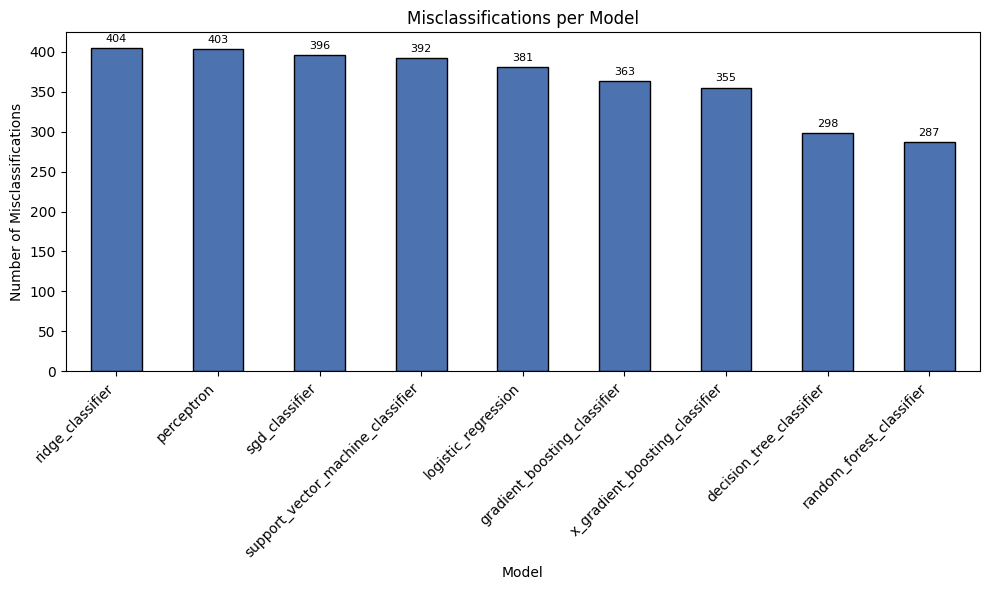

                            Model  Mis‑classified  Correctly classified  Total classified    N
         random_forest_classifier          63.87%                36.13%           100.00% 4846
              logistic_regression          56.13%                43.87%           100.00% 4846
                   sgd_classifier          53.16%                46.84%           100.00% 4846
   x_gradient_boosting_classifier          52.66%                47.34%           100.00% 4846
     gradient_boosting_classifier          51.94%                48.06%           100.00% 4846
support_vector_machine_classifier          50.04%                49.96%           100.00% 4846
                       perceptron          47.73%                52.27%           100.00% 4846
         decision_tree_classifier          47.15%                52.85%           100.00% 4846
                 ridge_classifier          46.00%                54.00%           100.00% 4846


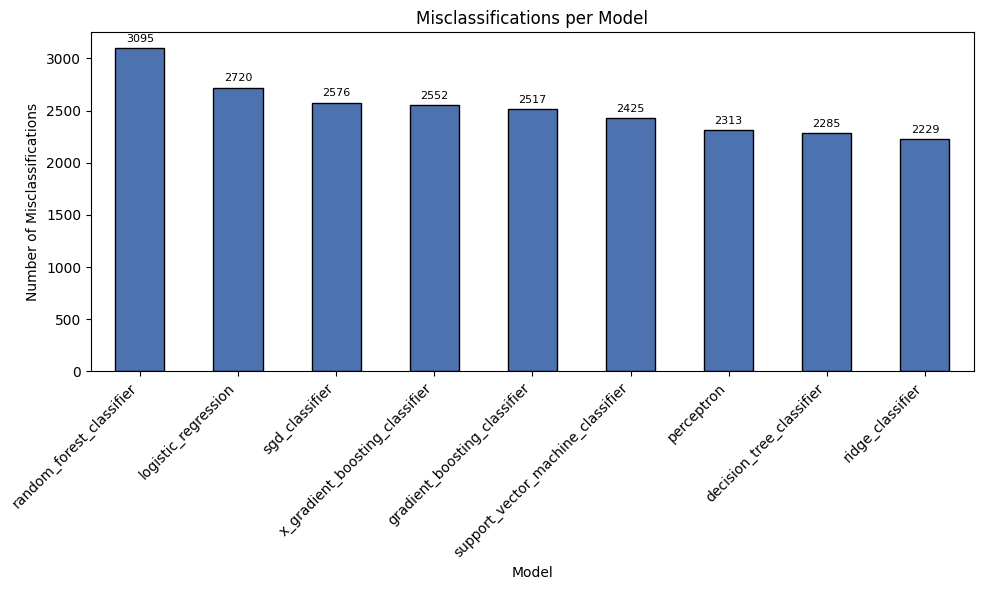

                            Model  Mis‑classified  Correctly classified  Total classified    N
         random_forest_classifier           3.53%                96.47%           100.00% 4846
         decision_tree_classifier           3.30%                96.70%           100.00% 4846
   x_gradient_boosting_classifier           2.13%                97.87%           100.00% 4846
     gradient_boosting_classifier           1.96%                98.04%           100.00% 4846
              logistic_regression           1.59%                98.41%           100.00% 4846
support_vector_machine_classifier           1.36%                98.64%           100.00% 4846
                   sgd_classifier           1.28%                98.72%           100.00% 4846
                       perceptron           1.13%                98.87%           100.00% 4846
                 ridge_classifier           1.11%                98.89%           100.00% 4846


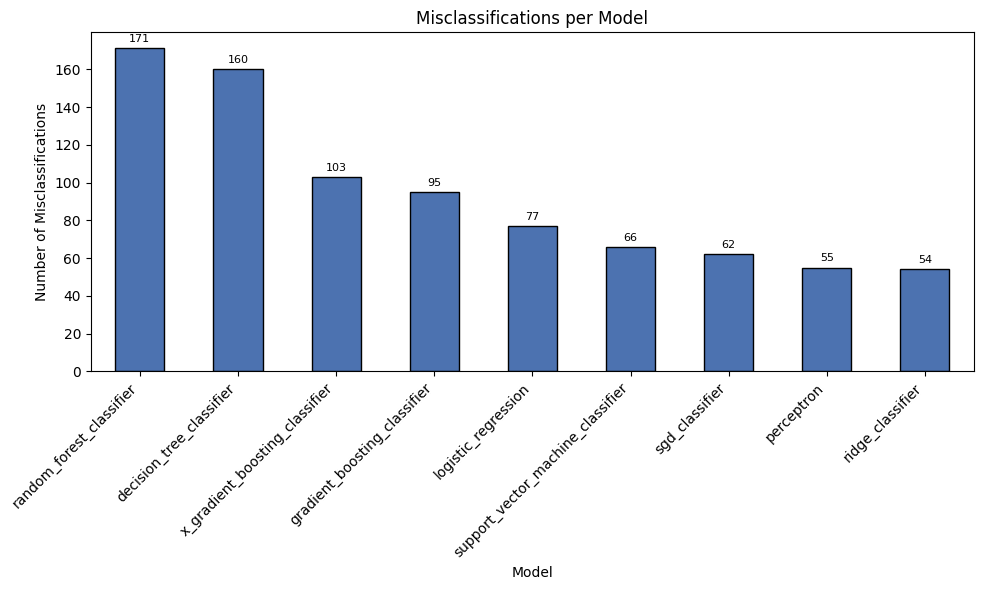

                            Model  Mis‑classified  Correctly classified  Total classified    N
                 ridge_classifier          44.55%                55.45%           100.00% 4846
         decision_tree_classifier          43.40%                56.60%           100.00% 4846
                       perceptron          42.82%                57.18%           100.00% 4846
support_vector_machine_classifier          40.51%                59.49%           100.00% 4846
     gradient_boosting_classifier          38.61%                61.39%           100.00% 4846
   x_gradient_boosting_classifier          37.89%                62.11%           100.00% 4846
                   sgd_classifier          37.39%                62.61%           100.00% 4846
              logistic_regression          34.42%                65.58%           100.00% 4846
         random_forest_classifier          26.68%                73.32%           100.00% 4846


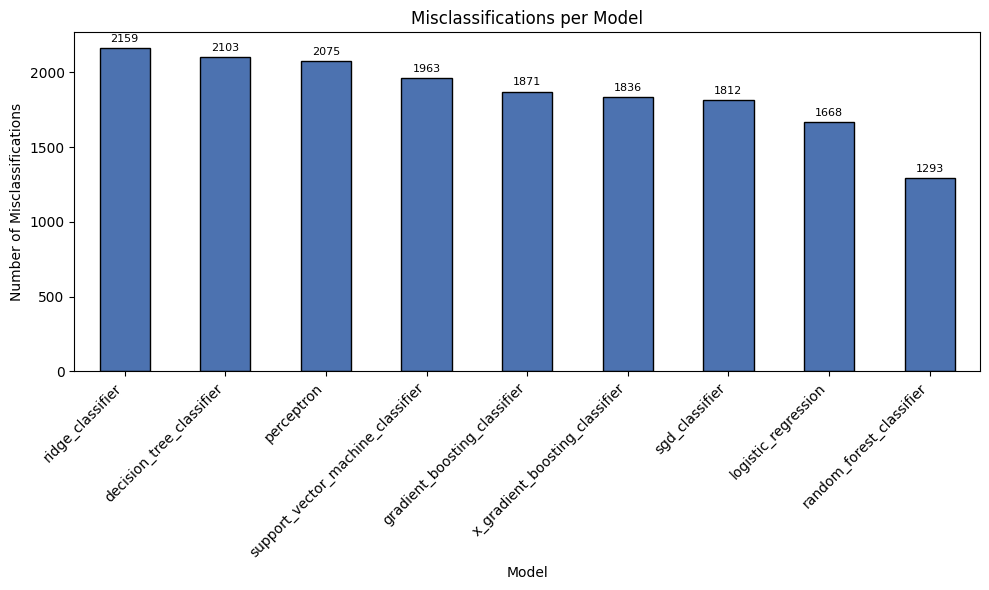

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1️⃣  Count the number of mismatches (i.e. rows) per model
# ------------------------------------------------------------------
for classification_df in classification_dfs:
    # model_names = classification_df['Model Name'].value_counts()
    miscounts = classification_df['Model Name'].value_counts()
    misclassified_ratio = (miscounts / len(model_results_df))
    properly_classified_ratio = 1 - misclassified_ratio # Should match classification
    total_classified_ratio = misclassified_ratio + properly_classified_ratio
    # print(f"{misclassified_ratio}, {properly_classified_ratio} = {total_classified_ratio}")
    # ------------------------------------------------------------------
    # 3.  Pretty‑print: one row per model, percentages to 2 decimals
    # ------------------------------------------------------------------
    ratios_df = pd.DataFrame({
        'Model': miscounts.index,
        'Mis‑classified': misclassified_ratio,
        'Correctly classified': properly_classified_ratio,
        'Total classified': total_classified_ratio,
        'N': len(model_results_df),
    })

    print(ratios_df.to_string(index=False,
                            float_format=lambda x: f'{x:.2%}'))
    # ------------------------------------------------------------------
    # 2️⃣  Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))

    # bar chart: one bar per model
    miscounts.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='black')

    # aesthetics
    ax.set_xlabel('Model')
    ax.set_ylabel('Number of Misclassifications')
    ax.set_title('Misclassifications per Model')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # show exact count on top of each bar
    for bar in ax.patches:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

                            Model  Mis‑classified  Correctly classified  Total classified    N
                 ridge_classifier           8.34%                91.66%           100.00% 4846
                       perceptron           8.32%                91.68%           100.00% 4846
                   sgd_classifier           8.17%                91.83%           100.00% 4846
support_vector_machine_classifier           8.09%                91.91%           100.00% 4846
              logistic_regression           7.86%                92.14%           100.00% 4846
     gradient_boosting_classifier           7.49%                92.51%           100.00% 4846
   x_gradient_boosting_classifier           7.33%                92.67%           100.00% 4846
         decision_tree_classifier           6.15%                93.85%           100.00% 4846
         random_forest_classifier           5.92%                94.08%           100.00% 4846


/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_82351/3045716345.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ratios_df['Model'], rotation=45, ha='right')


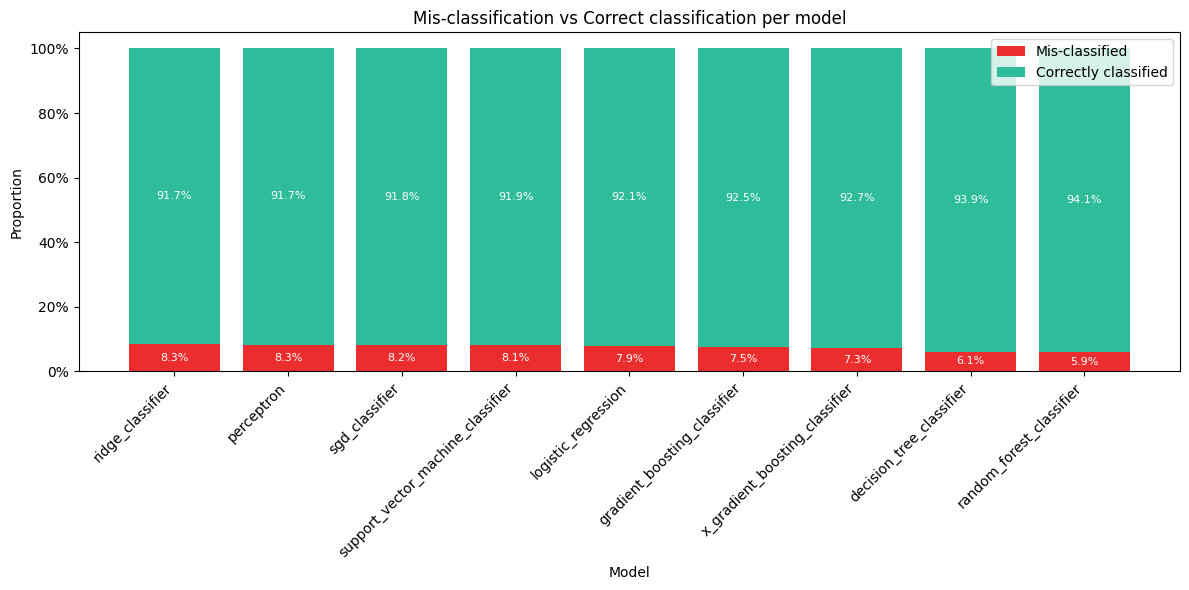

                            Model  Mis‑classified  Correctly classified  Total classified    N
         random_forest_classifier          63.87%                36.13%           100.00% 4846
              logistic_regression          56.13%                43.87%           100.00% 4846
                   sgd_classifier          53.16%                46.84%           100.00% 4846
   x_gradient_boosting_classifier          52.66%                47.34%           100.00% 4846
     gradient_boosting_classifier          51.94%                48.06%           100.00% 4846
support_vector_machine_classifier          50.04%                49.96%           100.00% 4846
                       perceptron          47.73%                52.27%           100.00% 4846
         decision_tree_classifier          47.15%                52.85%           100.00% 4846
                 ridge_classifier          46.00%                54.00%           100.00% 4846


/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_82351/3045716345.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ratios_df['Model'], rotation=45, ha='right')


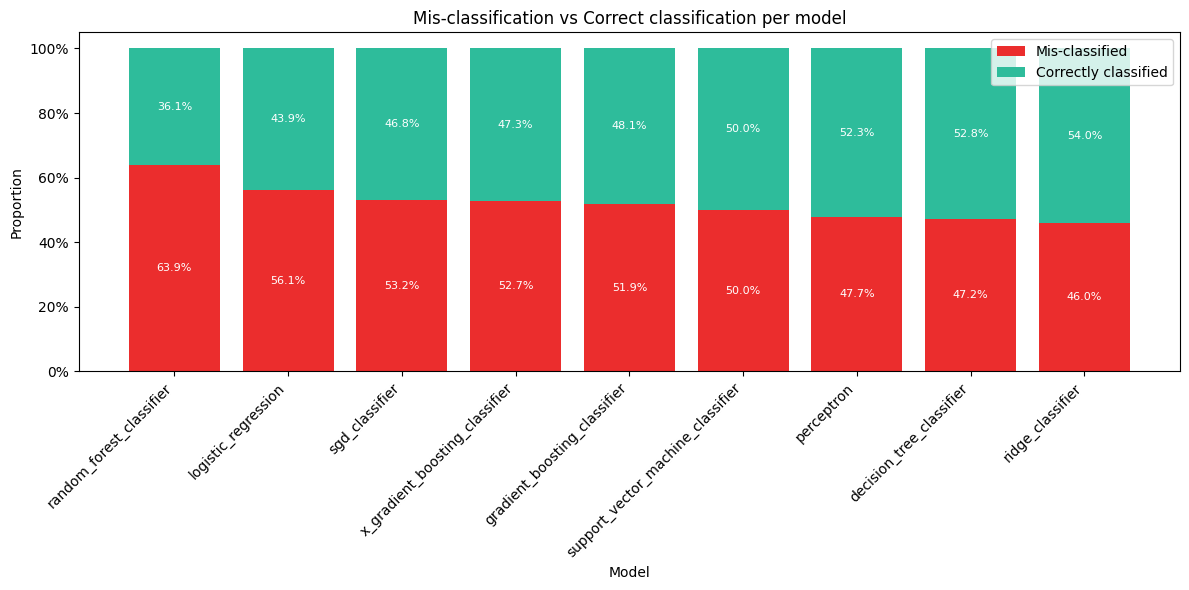

                            Model  Mis‑classified  Correctly classified  Total classified    N
         random_forest_classifier           3.53%                96.47%           100.00% 4846
         decision_tree_classifier           3.30%                96.70%           100.00% 4846
   x_gradient_boosting_classifier           2.13%                97.87%           100.00% 4846
     gradient_boosting_classifier           1.96%                98.04%           100.00% 4846
              logistic_regression           1.59%                98.41%           100.00% 4846
support_vector_machine_classifier           1.36%                98.64%           100.00% 4846
                   sgd_classifier           1.28%                98.72%           100.00% 4846
                       perceptron           1.13%                98.87%           100.00% 4846
                 ridge_classifier           1.11%                98.89%           100.00% 4846


/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_82351/3045716345.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ratios_df['Model'], rotation=45, ha='right')


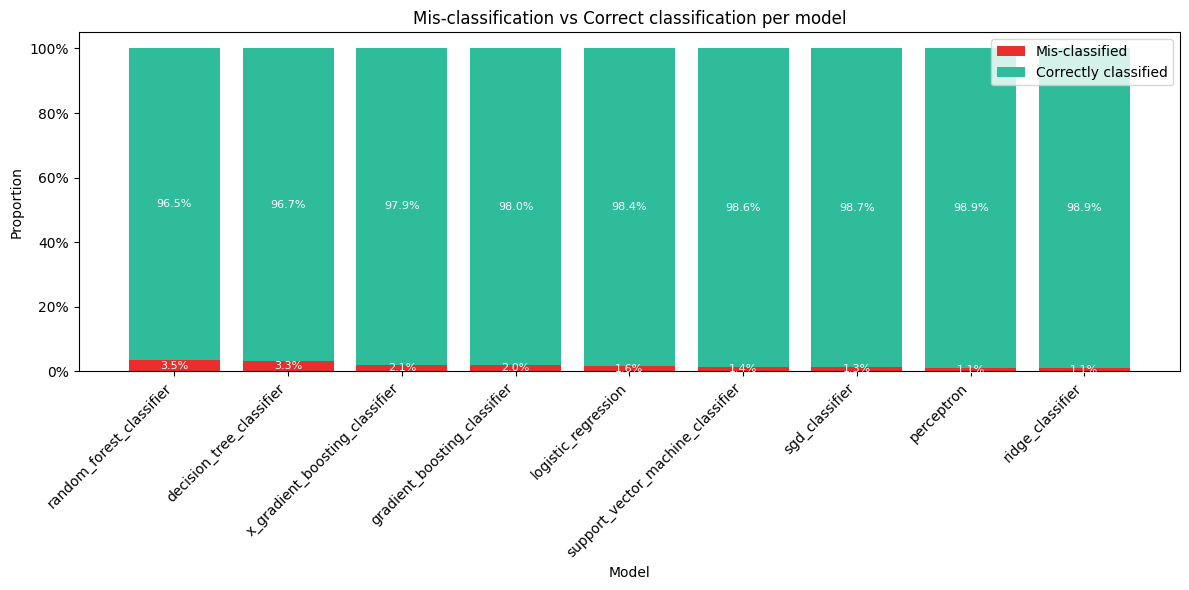

                            Model  Mis‑classified  Correctly classified  Total classified    N
                 ridge_classifier          44.55%                55.45%           100.00% 4846
         decision_tree_classifier          43.40%                56.60%           100.00% 4846
                       perceptron          42.82%                57.18%           100.00% 4846
support_vector_machine_classifier          40.51%                59.49%           100.00% 4846
     gradient_boosting_classifier          38.61%                61.39%           100.00% 4846
   x_gradient_boosting_classifier          37.89%                62.11%           100.00% 4846
                   sgd_classifier          37.39%                62.61%           100.00% 4846
              logistic_regression          34.42%                65.58%           100.00% 4846
         random_forest_classifier          26.68%                73.32%           100.00% 4846


/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_82351/3045716345.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ratios_df['Model'], rotation=45, ha='right')


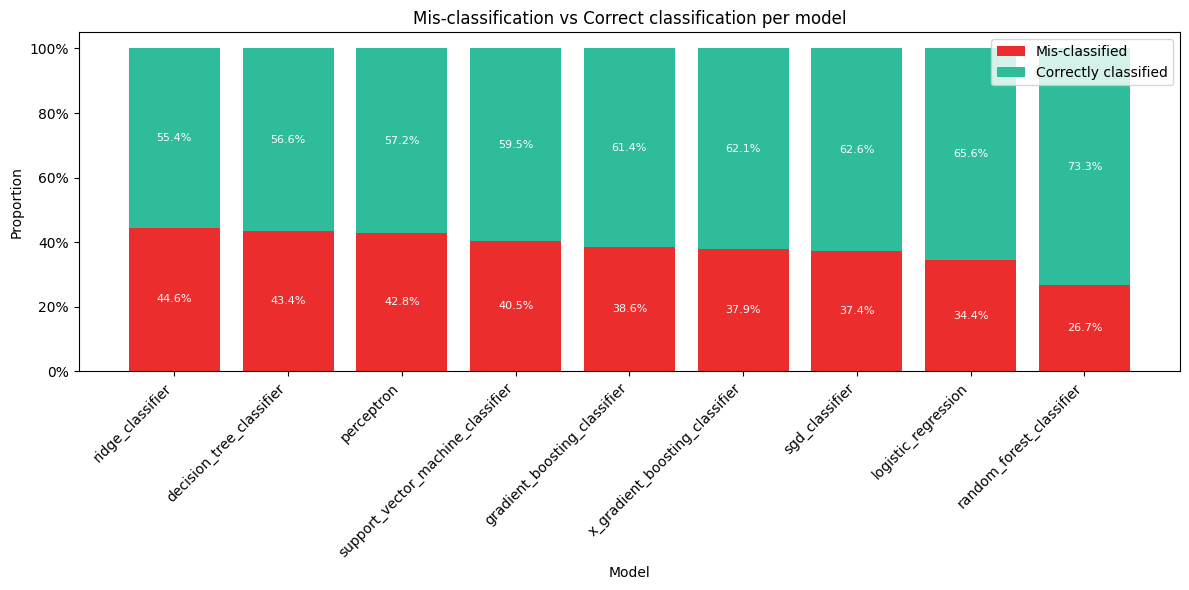

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1️⃣  Prepare the data ------------------------------------------------
# -------------------------------------------------------------

for classification_df in classification_dfs:
    # model_names = classification_df['Model Name'].value_counts()
    miscounts = classification_df['Model Name'].value_counts()
    misclassified_ratio      = miscounts / len(model_results_df)        # proportion that were wrong
    properly_classified_ratio= 1 - misclassified_ratio                # proportion that were right
    total_classified_ratio   = misclassified_ratio + properly_classified_ratio  # = 1

    # DataFrame ready for printing / plotting
    ratios_df = pd.DataFrame(
        {
            'Model': miscounts.index,
            'Mis‑classified': misclassified_ratio,
            'Correctly classified': properly_classified_ratio,
            'Total classified': total_classified_ratio,
            'N': len(model_results_df),
        }
    )

    print(ratios_df.to_string(index=False, float_format=lambda v: f'{v:.2%}'))

    # -------------------------------------------------------------
    # 2️⃣  Plot the stacked bar ------------------------------------
    # -------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 6))

    # ── split the bars into two stacks ----------------------------
    ax.bar(
        ratios_df.index,
        ratios_df['Mis‑classified'],
        width=0.8,
        color='#EB2D2D',
        label='Mis‑classified'
    )

    ax.bar(
        ratios_df.index,
        ratios_df['Correctly classified'],
        width=0.8,
        bottom=ratios_df['Mis‑classified'],
        color='#2EBC9B',
        label='Correctly classified'
    )

    # ── cosmetics --------------------------------------------------
    ax.set_xlabel('Model')
    ax.set_ylabel('Proportion')
    ax.set_title('Mis‑classification vs Correct classification per model')
    ax.set_xticklabels(ratios_df['Model'], rotation=45, ha='right')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
    ax.legend()

    # ── annotate bars with percentage values -----------------------
    for i, (mis, cor) in enumerate(zip(ratios_df['Mis‑classified'],
                                        ratios_df['Correctly classified'])):
        ax.text(i, mis / 2, f'{mis:.1%}', ha='center', va='center', color='white', fontsize=8)
        ax.text(i, mis + cor / 2,
                f'{cor:.1%}',
                ha='center',
                va='center',
                color='white',
                fontsize=8)

    plt.tight_layout()
    plt.show()

## Linguistic Features

In [31]:
pd.set_option('max_colwidth', 800)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_columns', 40)
# pd.set_option('display.max_rows', None)

In [32]:
filt_tp = (mv_with_class_df['Class'] == 'TP')
tp_mv_df = mv_with_class_df[filt_tp]
tp_mv_df.head(3)

,Base Sentence,Sentence Label,Base Sentence Embedding,Majority Vote,Meta Data,Class
0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....,1,"{'perceptron': 1, 'sgd_classifier': 1, 'logistic_regression': 1, 'ridge_classifier': 1, 'decision_tree_classifier': 0, 'random_forest_classifier': 1, 'gradient_boosting_classifier': 1, 'support_vector_machine_classifier': 1, 'x_gradient_boosting_classifier': 1}",TP
1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....,1,"{'perceptron': 1, 'sgd_classifier': 1, 'logistic_regression': 0, 'ridge_classifier': 0, 'decision_tree_classifier': 1, 'random_forest_classifier': 1, 'gradient_boosting_classifier': 1, 'support_vector_machine_classifier': 0, 'x_gradient_boosting_classifier': 1}",TP
2,TeliaSonera TLSN said the offer is in line with its strategy to increase its ownership in core business holdings and would strengthen Eesti Telekom 's offering to its customers .,1,[ 1.15080299e-02 1.98225155e-01 1.95062440e-02 -5.97744621e-02\n 1.75585955e-01 -1.25474662e-01 -3.72287892e-02 -2.83286646e-02\n -3.56662273e-02 1.96045303e+00 -2.79843062e-01 -1.04898110e-01\n 4.49508205e-02 1.31481076e-02 6.55795187e-02 -4.11130209e-03\n -5.56710083e-03 1.11790729e+00 -1.21459611e-01 -9.75316912e-02\n 2.18506586e-02 1.38311490e-01 9.17155594e-02 -5.85136563e-02\n 1.03342809e-01 7.32071251e-02 -3.92427929e-02 1.13294438e-01\n -1.07247204e-01 5.58346435e-02 -9.28281173e-02 5.48683619e-03\n -1.84886660e-02 5.24056628e-02 4.05881368e-02 -8.35432187e-02\n 1.13391867e-02 2.78038122e-02 -5.44880610e-03 -1.02035753e-01\n -6.69988245e-02 7.79658780e-02 5.37769347e-02 -1.39616817e-01\n 2.96867881e-02 1.13102477e-02 -3.53476144e-02 -1.88835058e-02\n -4....,1,"{'perceptron': 1, 'sgd_classifier': 1, 'logistic_regression': 1, 'ridge_classifier': 1, 'decision_tree_classifier': 1, 'random_forest_classifier': 1, 'gradient_boosting_classifier': 1, 'support_vector_machine_classifier': 1, 'x_gradient_boosting_classifier': 1}",TP


In [33]:
noun_aux_verb_sentences = []
disable_components = []
class_names = mv_with_class_df['Class'].unique()
for class_name in class_names:
    print(f"CLASS: {class_name}")
    filt_class_name = (mv_with_class_df['Class'] == class_name)
    class_df = mv_with_class_df[filt_class_name]
    spacy_fe = SpacyFeatureExtraction(class_df, 'Base Sentence')
    ner_df = spacy_fe.extract_ner_features(disable_components, visualize=False)
    pos_df = spacy_fe.extract_pos_features(disable_components, visualize=False)
    print(pos_df['Term'].value_counts())
    print(pos_df['Dependency'].value_counts())
    print(pos_df['POS Label'].value_counts())

    # Get sentences that contain NOUN + AUX + VERB
    noun_sentences = set(pos_df[pos_df['POS Label'] == 'NOUN']['Sentence'].tolist())
    aux_sentences = set(pos_df[pos_df['POS Label'] == 'AUX']['Sentence'].tolist())
    verb_sentences = set(pos_df[pos_df['POS Label'] == 'VERB']['Sentence'].tolist())

    # Sentences that contain all three POS tags
    class_noun_aux_verb_sentences = noun_sentences & aux_sentences & verb_sentences

    # Track class name and sentences
    for sentence in class_noun_aux_verb_sentences:
        noun_aux_verb_sentences.append({
            'Class': class_name,
            'Sentence': sentence
        })

    print(f"\nCLASS: {class_name}")
    print(f"Number of sentences with NOUN + AUX + VERB: {len(class_noun_aux_verb_sentences)}")
    for sentence in list(class_noun_aux_verb_sentences)[:3]:
        print(f"  - {sentence}")
    print()

CLASS: TP

EXTRACTING NER FEATURES


Extracting NER Features: 100%|██████████| 388/388 [00:01<00:00, 349.75doc/s]



DONE EXTRACTING NER FEATURES

EXTRACTING POS FEATURES


Extracting POS Features: 100%|██████████| 388/388 [00:01<00:00, 353.79doc/s]



DONE EXTRACTING POS FEATURES
Term
the           399
              388
.             385
to            280
,             251
             ... 
Kalmar          1
Capitex         1
newspapers      1
Ignatius        1
RESULTS         1
Name: count, Length: 2099, dtype: int64
Dependency
prep         905
pobj         879
punct        823
det          692
compound     610
amod         547
nsubj        481
aux          473
ROOT         396
             388
dobj         305
nummod       222
advmod       206
conj         185
poss         165
cc           163
auxpass      151
xcomp        129
ccomp        127
nsubjpass    122
case          84
npadvmod      72
acomp         69
mark          62
advcl         57
nmod          55
quantmod      55
appos         52
relcl         47
attr          38
acl           31
pcomp         27
prt           17
agent         15
neg            9
dep            7
dative         4
csubj          3
expl           3
preconj        3
oprd           3
parataxis      2
pr

...


DONE EXTRACTING POS FEATURES
Term
            1852
.           1831
the         1760
,           1351
to          1200
            ... 
Backup         1
protects       1
stored         1
Higher         1
posting        1
Name: count, Length: 6821, dtype: int64
Dependency
punct        4870
compound     4362
prep         4263
pobj         4161
det          3405
amod         2570
nsubj        2401
ROOT         1921
             1852
dobj         1754
aux          1750
conj         1249
cc           1069
advmod       1003
nummod        931
poss          841
ccomp         520
appos         519
auxpass       462
xcomp         449
case          429
nsubjpass     400
nmod          368
npadvmod      358
acl           287
attr          279
relcl         277
advcl         262
mark          251
acomp         223
pcomp         155
quantmod      147
prt            88
neg            86
agent          80
dep            40
dative         37
predet         18
csubj          16
expl           15
oprd   

Extracting NER Features: 100%|██████████| 2536/2536 [00:08<00:00, 313.90doc/s]



DONE EXTRACTING NER FEATURES

EXTRACTING POS FEATURES


Extracting POS Features: 100%|██████████| 2536/2536 [00:08<00:00, 311.67doc/s]



DONE EXTRACTING POS FEATURES
Term
,                      3011
                       2536
.                      2533
the                    2461
of                     1853
                       ... 
www.upm-kymmene.com       1
thirty                    1
seventeen                 1
Free                      1
241.1                     1
Name: count, Length: 8761, dtype: int64
Dependency
pobj         7801
prep         7778
punct        7591
compound     7136
det          4300
amod         3843
nummod       3033
nsubj        2998
ROOT         2684
             2536
conj         2298
dobj         1724
cc           1620
nmod         1168
appos        1086
advmod       1066
poss          970
npadvmod      810
aux           759
case          562
auxpass       418
ccomp         393
nsubjpass     386
attr          371
advcl         352
acl           289
mark          242
quantmod      231
relcl         184
pcomp         136
agent         124
prt           107
acomp         105
dep         

In [34]:
ner_df

,Sentence,Term,NER Label,Unique NER Label,Start Char,End Char
0,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",Elcoteq,ORG,ORG_1,46,53
1,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",tens,CARDINAL,CARDINAL_1,67,71
2,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",Tallinn,GPE,GPE_1,94,101
3,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",daily,DATE,DATE_1,202,207
4,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",Postimees,PERSON,PERSON_1,208,217
...,...,...,...,...,...,...
11969,"Sales in Finland decreased by 10.5 % in January , while sales outside Finland dropped by 17 % .",10.5 %,PERCENT,PERCENT_469,30,36
11970,"Sales in Finland decreased by 10.5 % in January , while sales outside Finland dropped by 17 % .",January,DATE,DATE_1776,40,47
11971,"Sales in Finland decreased by 10.5 % in January , while sales outside Finland dropped by 17 % .",Finland,GPE,GPE_1642,70,77
11972,"Sales in Finland decreased by 10.5 % in January , while sales outside Finland dropped by 17 % .",17 %,PERCENT,PERCENT_470,89,93


In [35]:
pos_df

,Sentence,Term,Lemma,POS Label,Detailed POS Label,Dependency,Shape,Is Alpha,Stop Word,Unique POS Label,...,Definite,Degree,SubCat,Animacy,Acc,Gen,Loc,Ins,Parat,Prep
0,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",The,the,DET,DT,det,Xxx,True,True,DET_1,...,[Def],,,,,,,,,
1,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",international,international,ADJ,JJ,amod,xxxx,True,False,ADJ_1,...,,[Pos],,,,,,,,
2,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",electronic,electronic,ADJ,JJ,amod,xxxx,True,False,ADJ_2,...,,[Pos],,,,,,,,
3,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",industry,industry,NOUN,NN,compound,xxxx,True,False,NOUN_1,...,,,,,,,,,,
4,"The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .",company,company,NOUN,NN,nsubj,xxxx,True,False,NOUN_2,...,,,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65388,"Sales in Finland decreased by 10.5 % in January , while sales outside Finland dropped by 17 % .",by,by,ADP,IN,prep,xx,True,True,ADP_7881,...,,,,,,,,,,
65389,"Sales in Finland decreased by 10.5 % in January , while sales outside Finland dropped by 17 % .",17,17,NUM,CD,nummod,dd,False,False,NUM_4800,...,,,,,,,,,,
65390,"Sales in Finland decreased by 10.5 % in January , while sales outside Finland dropped by 17 % .",%,%,NOUN,NN,pobj,%,False,False,NOUN_13446,...,,,,,,,,,,
65391,"Sales in Finland decreased by 10.5 % in January , while sales outside Finland dropped by 17 % .",.,.,PUNCT,.,punct,.,False,False,PUNCT_7501,...,,,,,,,,,,


In [36]:
# Create dataframe
noun_aux_verb_df = pd.DataFrame(noun_aux_verb_sentences, columns=['Class', 'Sentence'])
noun_aux_verb_df

,Class,Sentence
0,TP,The desk will reach its full planned strength of ten persons in autumn 2007 .
1,TP,L&T has also made a commitment to redeem the remaining shares by the end of 2011 .
2,TP,"Nokia will continue to invest in future development of Qt , and Digia will be responsible for commercial licensing and services business ."
3,TP,"By acquiring RCP , we can combine our strong knowhow with the expertise of a solid local company ."
4,TP,However short-term rentals are becoming more popular .
...,...,...
2705,TN,The original contract was signed last summer .
2706,TN,Finnish electronics manufacturer PKC Group Oyj ( OMX Helsinki : PKC1V ) said on Wednesday ( 31 December ) that it has completed the acquisition of MAN Nutzfahrzeuge AG 's cable harness business from MAN Star Trucks & Buses Spolka zoo in Poland .
2707,TN,"In addition , the production at the Varpaisj+_ rvi factory will be stopped at the beginning of April 2009 ."
2708,TN,"Metsa-Botnia will finance the payment of dividends , the repayment of capital and the repurchase of its own shares with the funds deriving from its divestment of the Uruguay operations , and shares in Pohjolan Voima , and by utilising its existing financing facilities ."


In [37]:
noun_aux_verb_df['Class'].value_counts()

Class
FP    1305
TN    1042
TP     315
FN      48
Name: count, dtype: int64

In [38]:
pd.set_option('max_colwidth', 800)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_columns', 40)
# pd.set_option('display.max_rows', None)

In [39]:
filt_nav = noun_aux_verb_df['Class'] == "TP"
tp_nav_df = noun_aux_verb_df[filt_nav]
len(tp_nav_df)

315

In [40]:
tp_nav_df

,Class,Sentence
0,TP,The desk will reach its full planned strength of ten persons in autumn 2007 .
1,TP,L&T has also made a commitment to redeem the remaining shares by the end of 2011 .
2,TP,"Nokia will continue to invest in future development of Qt , and Digia will be responsible for commercial licensing and services business ."
3,TP,"By acquiring RCP , we can combine our strong knowhow with the expertise of a solid local company ."
4,TP,However short-term rentals are becoming more popular .
...,...,...
310,TP,Net sales in 2008 are expected to be on the same level as in 2007 .
311,TP,- Net sales for the period are expected to fall well below that of last year and the result after non-recurring items is expected to be in the red .
312,TP,"However , sales volumes in the food industry are expected to remain at relatively good levels in Finland and in Scandinavia , Atria said ."
313,TP,This will bring cost savings of about EUR 3mn a year .


In [41]:
filt_nav = noun_aux_verb_df['Class'] == "FN"
fn_nav_df = noun_aux_verb_df[filt_nav]
len(fn_nav_df)

48

In [42]:
fn_nav_df

,Class,Sentence
315,FN,"Earnings per share EPS are seen at EUR 0.56 , up from EUR 0.38 ."
316,FN,"By the end of 2006 , the number of joint branch offices will total 170 ."
317,FN,"Subscribers of China Unicom , the nation 's second largest mobile phone operator after China Mobile , are expected to release pictures , videos and blog on the Internet via mobile phones as of March 2008 ."
318,FN,Stora Enso Oyj said its second-quarter result would fall by half compared with the same period in 2007 .
319,FN,"Demonstrations of the broad capabilities of the Mobility Business Suite will be organized during the 3GSM World Congress in Barcelona , from February 12th to 15th ."
320,FN,"LLC , a voice and data management solution provider to wireless companies with operations worldwide , will be transferring its U.S. deployment operations to the Finnish mobile giant , which includes civil works and site acquisition services ."
321,FN,"Konecranes has previously communicated an estimated reduction of about 1,600 employees on group level in 2009 ."
322,FN,"According to Scanfil , demand for telecommunications network products has fluctuated significantly in the third quarter of 2006 , and the situation is expected to remain unstable for the rest of the year ."
323,FN,As a result of the negotiations the employment of 130 blue - and white-collar employees at the Oulu plant would be terminated .
324,FN,The value of the three-year contract is estimated at EUR40m .
